### Performing K-Means Clustering on a Dataset

##### Name: Ananya Agrawal
##### Andrew ID: ananyaa2

##### 38615: Computational Modelling, Statistical Analysis and Machine Learning in Science - Homework 2


### Add import statements


In [ ]:
# Setup libraries

!pip install umap-learn
!pip install kmodes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, SpectralClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from kmodes.kmodes import KModes

from sklearn.metrics.pairwise import cosine_distances
from scipy.spatial.distance import pdist, squareform

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram

### Loading the dataset

In [ ]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/ananya0809/EDA_PCA_ML/refs/heads/main/hw2_dataset.csv')
print(df.shape)
print(df.head())
print(df.describe())

(969, 1025)
                            ID  D_0  D_1  D_2  D_3  D_4  D_5  D_6  D_7  D_8  \
0  AAEAMMIUQZAASJ-MRXNPFEDSA-N    1    1    1    1    1    1    1    0    1   
1  AAEFNWQXBPYXAC-UHFFFAOYSA-N    1    1    1    1    0    1    1    1    0   
2  AAMHSIWFDKXUMZ-UHFFFAOYSA-N    1    1    1    1    1    1    0    1    1   
3  AAPQXEOSVSLLMB-UHFFFAOYSA-N    1    1    1    1    0    1    1    1    1   
4  AARXXEHXOBTROW-UHFFFAOYSA-N    1    1    1    1    1    1    1    0    1   

   ...  D_1014  D_1015  D_1016  D_1017  D_1018  D_1019  D_1020  D_1021  \
0  ...       1       1       1       1       1       1       0       1   
1  ...       1       0       1       1       1       0       0       1   
2  ...       1       1       1       1       1       1       0       0   
3  ...       1       1       1       1       1       1       1       1   
4  ...       1       1       1       1       1       1       0       1   

   D_1022  D_1023  
0       1       1  
1       1       1  
2       

### Performing K-Means

In [ ]:
# data to be used
# we remove first row because it has ID which is not required
X = df.iloc[:, 1:].values

### Determining optimal number of Clusters using:
1. Elbow Method
2. Silhouette Method

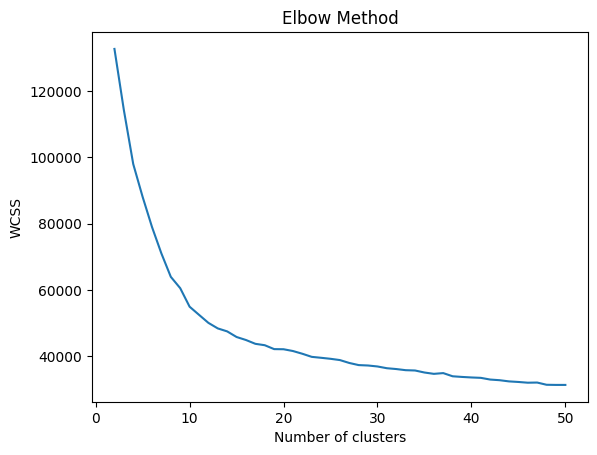

In [ ]:
# check for clusters from 2 to 50
k_means_range = range(2, 51)

# elbow method
wcss = []
for i in k_means_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.plot(k_means_range, wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

For n_clusters = 2, the average silhouette score is 0.1686
For n_clusters = 3, the average silhouette score is 0.2153
For n_clusters = 4, the average silhouette score is 0.2672
For n_clusters = 5, the average silhouette score is 0.2977
For n_clusters = 6, the average silhouette score is 0.3243
For n_clusters = 7, the average silhouette score is 0.3515
For n_clusters = 8, the average silhouette score is 0.3742
For n_clusters = 9, the average silhouette score is 0.3163
For n_clusters = 10, the average silhouette score is 0.3428
For n_clusters = 11, the average silhouette score is 0.3325
For n_clusters = 12, the average silhouette score is 0.3381
For n_clusters = 13, the average silhouette score is 0.3453
For n_clusters = 14, the average silhouette score is 0.3434
For n_clusters = 15, the average silhouette score is 0.3383
For n_clusters = 16, the average silhouette score is 0.3358
For n_clusters = 17, the average silhouette score is 0.3002
For n_clusters = 18, the average silhouette scor

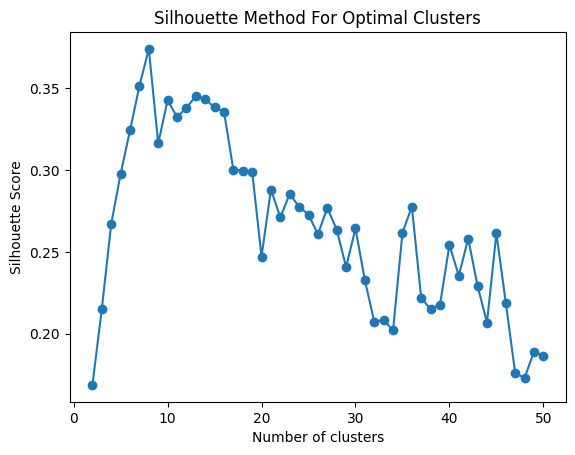

In [ ]:
# silhouette score
silhouette_scores = []

for n_clusters in k_means_range:
    # Perform k-means clustering
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f'For n_clusters = {n_clusters}, the average silhouette score is {silhouette_avg:.4f}')

# Plotting the silhouette scores
plt.plot(k_means_range, silhouette_scores, marker='o')
plt.title('Silhouette Method For Optimal Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

#### Based on above graphs. we find out number of cluster = 8 to be optimal

In [ ]:
N_CLUSTER = 8

### Performing clustering with different methods as implemented in Scikit-learn

K-mode Clustering with Hamming Distance (default)



Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 241442.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 241442.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 241442.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 241442.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 241442.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 70, cost: 222129.0
Run 1, iteration: 2/100, moves: 69, cost: 211646.0
Run 1, iteration: 3/100, moves: 24, cost: 210350.0
Run 1, iteration: 4/100, moves: 0, cost: 210350.0
Init: initializing centroids
Init: initializi

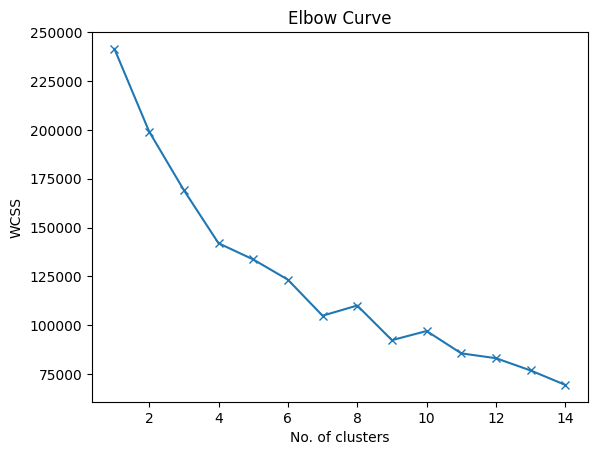

In [ ]:
# Elbow curve to find optimal K
cost = []
K = range(1,15)
for k in list(K):
	kmode = KModes(n_clusters=k, init = "random", n_init = 5, verbose=1)
	kmode.fit_predict(df)
	cost.append(kmode.cost_)

plt.plot(K, cost, 'x-')
plt.xlabel('No. of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Curve')
plt.show()


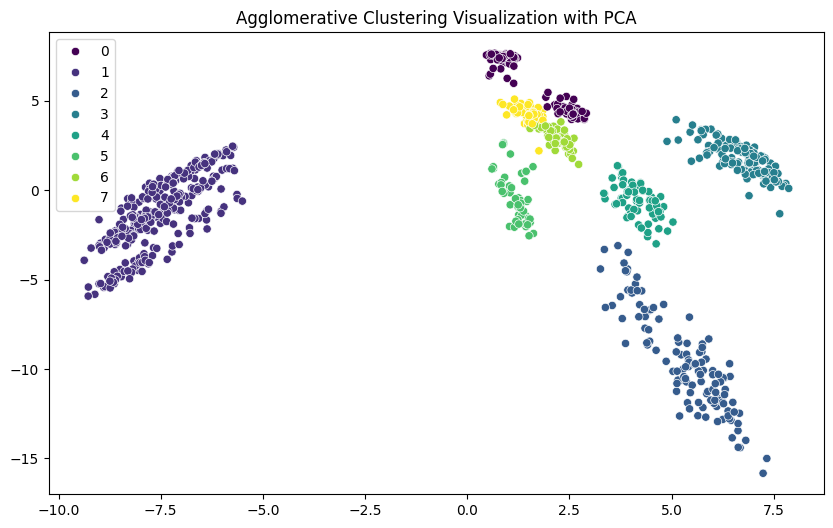

In [ ]:
# agglomerative
agg_cluster = AgglomerativeClustering(n_clusters=N_CLUSTER)
agg_labels = agg_cluster.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette='viridis', legend='full')
plt.title('Agglomerative Clustering Visualization with PCA')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Unique clusters identified by Spectral Clustering: {0, 1, 2, 3, 4, 5, 6, 7}


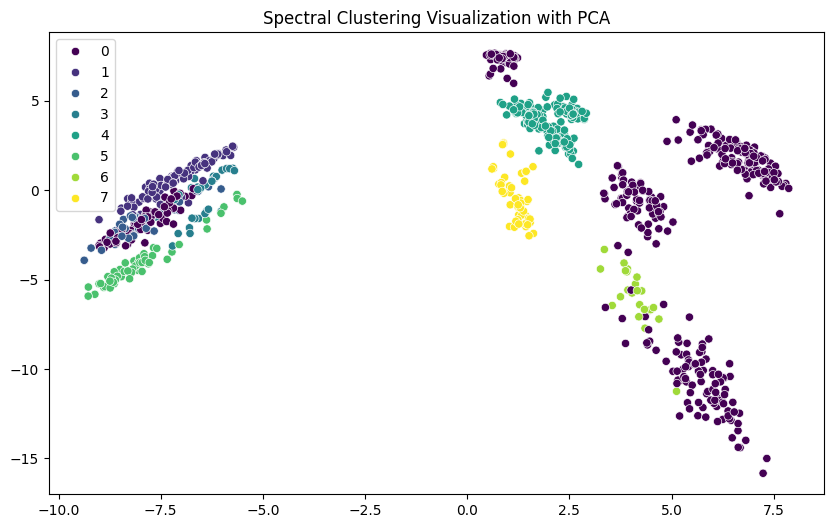

In [ ]:
# Spectral Clustering
spectral_cluster = SpectralClustering(n_clusters=N_CLUSTER, affinity='nearest_neighbors', random_state=42)
spectral_labels = spectral_cluster.fit_predict(X)

# Check the unique cluster labels
print(f"Unique clusters identified by Spectral Clustering: {set(spectral_labels)}")

# Visualization of clusters using PCA (PCA can be replaced with UMAP/t-SNE as well)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=spectral_labels, palette='viridis', legend='full')
plt.title('Spectral Clustering Visualization with PCA')
plt.show()

Unique clusters identified by Gaussian Mixture: {0, 1, 2, 3, 4, 5, 6, 7}


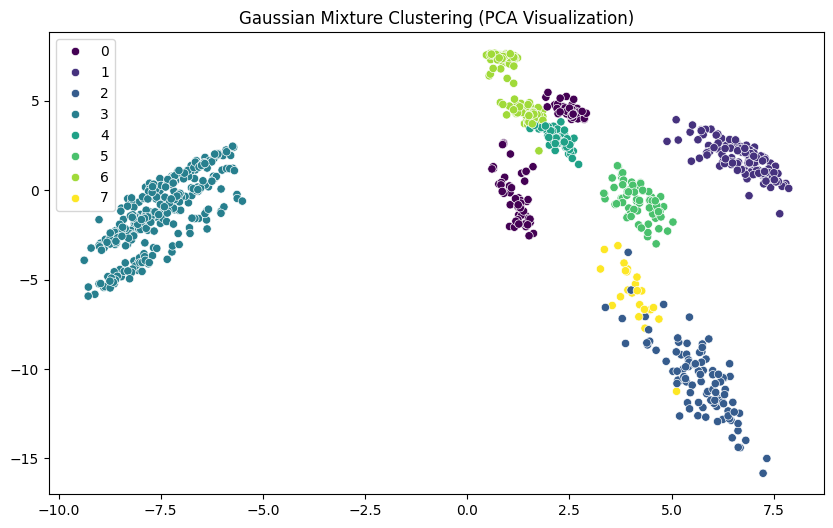

In [ ]:
# Gaussian Mixture Model
gmm = GaussianMixture(n_components=N_CLUSTER, random_state=42)
gmm_labels = gmm.fit_predict(X)  # Fit the model and predict cluster labels

# Check the unique cluster labels
print(f"Unique clusters identified by Gaussian Mixture: {set(gmm_labels)}")

# Visualization of clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='viridis', legend='full')
plt.title('Gaussian Mixture Clustering (PCA Visualization)')
plt.show()

Hierarchical Clustering (Dendogram) with Jaccard Distance (default)

<ipython-input-12-6e66f642b9b5>:5: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(jaccard_dist_matrix, method='complete')


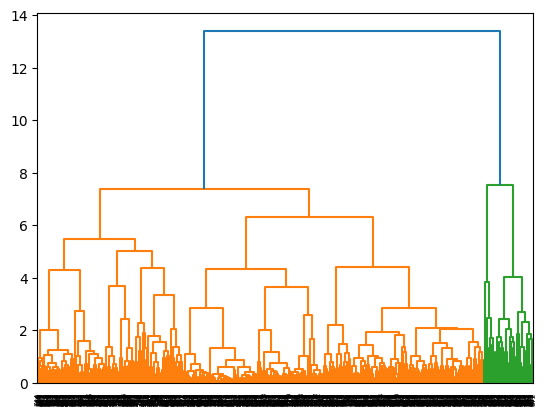

In [ ]:
# Calculate Jaccard distance matrix
jaccard_dist_matrix = squareform(pdist(X, metric='jaccard'))

# Perform hierarchical clustering (dendogram)
linkage_matrix = linkage(jaccard_dist_matrix, method='complete')

# Plot dendrogram
dendrogram(linkage_matrix)
plt.show()

### Clustering with different distance metrics (e.g. Cosine, Jaccard, etc.) on K-means, K-mode and Hierarchical Clustering, PCA is used for dimensionality reduction on K-means




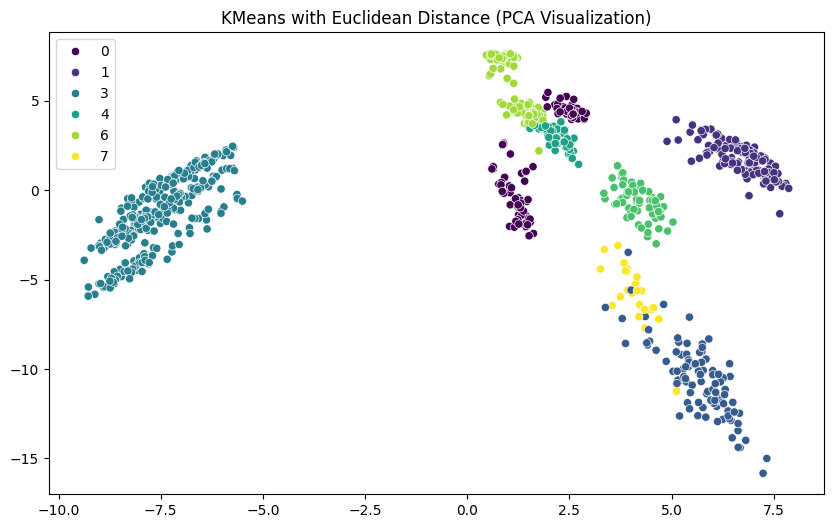

In [ ]:
# Applying KMeans with default Euclidean distance
kmeans = KMeans(n_clusters=N_CLUSTER, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Visualization with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis')
plt.title('KMeans with Euclidean Distance (PCA Visualization)')
plt.show()

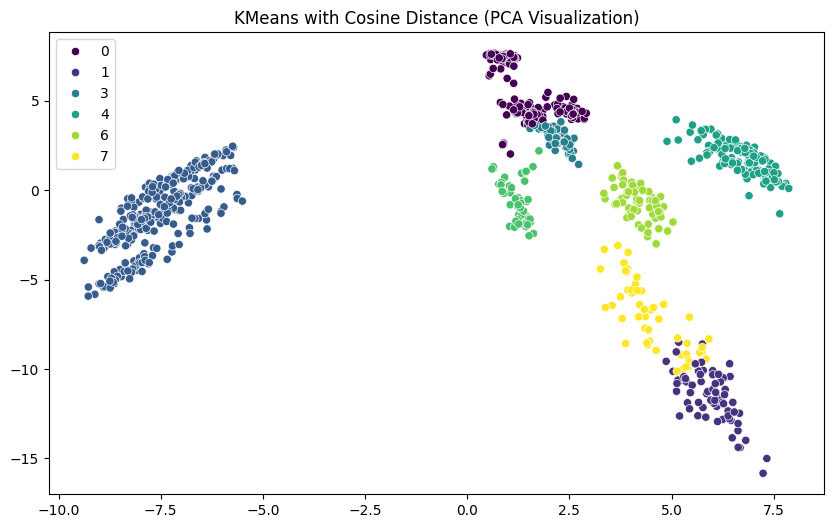

In [ ]:
cosine_dist_matrix = cosine_distances(X)

# Since KMeans uses Euclidean distance by default, we can apply KMeans on the precomputed distance matrix
# Use KMeans with the precomputed cosine distance
kmeans_cosine = KMeans(n_clusters=N_CLUSTER, random_state=42)
kmeans_cosine.fit(cosine_dist_matrix)
cosine_labels = kmeans_cosine.labels_

# Visualization with PCA
X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cosine_labels, palette='viridis')
plt.title('KMeans with Cosine Distance (PCA Visualization)')
plt.show()

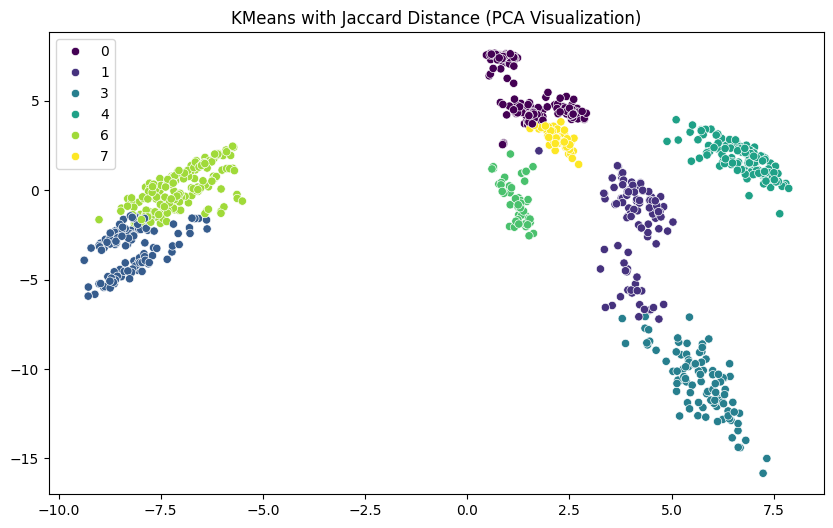

In [ ]:
# Compute Jaccard distance matrix (pdist returns condensed distance matrix, so we use squareform)
jaccard_dist_matrix = squareform(pdist(X, metric='jaccard'))

# Apply KMeans on the Jaccard distance matrix
kmeans_jaccard = KMeans(n_clusters=N_CLUSTER, random_state=42)
kmeans_jaccard.fit(jaccard_dist_matrix)
jaccard_labels = kmeans_jaccard.labels_

# Visualization with PCA
X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=jaccard_labels, palette='viridis')
plt.title('KMeans with Jaccard Distance (PCA Visualization)')
plt.show()

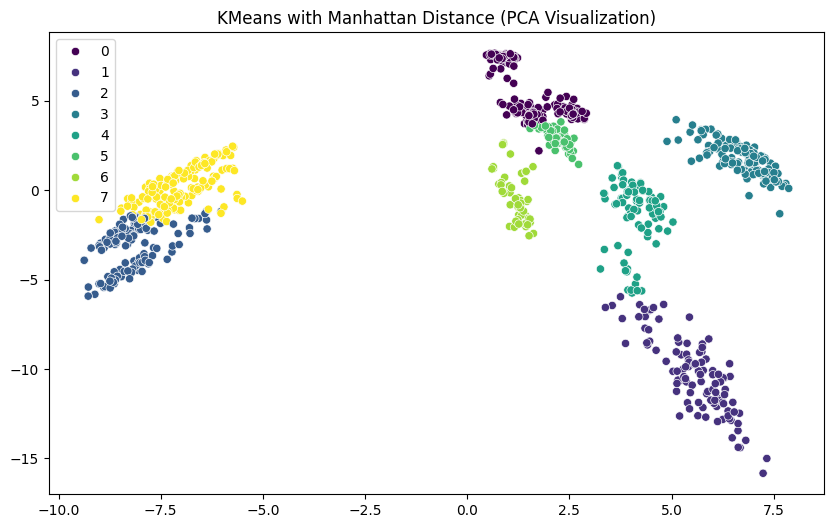

In [ ]:
# Compute Manhattan distance matrix
manhattan_dist_matrix = squareform(pdist(X, metric='cityblock'))

# Apply KMeans on the Manhattan distance matrix
kmeans_manhattan = KMeans(n_clusters=N_CLUSTER, random_state=42)
kmeans_manhattan.fit(manhattan_dist_matrix)
manhattan_labels = kmeans_manhattan.labels_

# Visualization with PCA
X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=manhattan_labels, palette='viridis', legend='full')
plt.title('KMeans with Manhattan Distance (PCA Visualization)')
plt.show()

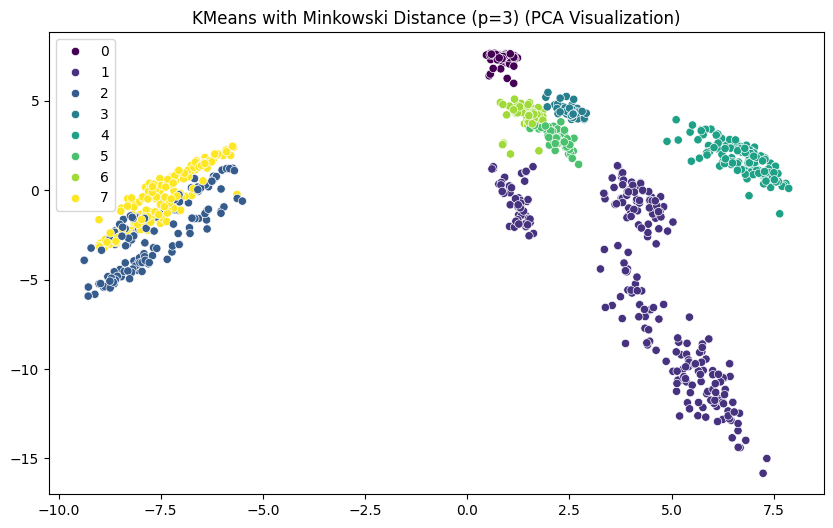

In [ ]:
# Define the value of p for Minkowski distance
p_value = 3  # You can change p_value as needed (1 = Manhattan, 2 = Euclidean)

# Compute Minkowski distance matrix
minkowski_dist_matrix = squareform(pdist(X, metric='minkowski', p=p_value))

# Apply KMeans on the Minkowski distance matrix
kmeans_minkowski = KMeans(n_clusters=N_CLUSTER, random_state=42)
kmeans_minkowski.fit(minkowski_dist_matrix)
minkowski_labels = kmeans_minkowski.labels_

# Visualization with PCA
X_pca = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=minkowski_labels, palette='viridis', legend='full')
plt.title(f'KMeans with Minkowski Distance (p={p_value}) (PCA Visualization)')
plt.show()

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 393, cost: 103341.0
Run 1, iteration: 2/100, moves: 70, cost: 98736.0
Run 1, iteration: 3/100, moves: 0, cost: 98736.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 266, cost: 144746.0
Run 2, iteration: 2/100, moves: 21, cost: 144705.0
Run 2, iteration: 3/100, moves: 0, cost: 144705.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 312, cost: 143738.0
Run 3, iteration: 2/100, moves: 54, cost: 143196.0
Run 3, iteration: 3/100, moves: 4, cost: 143176.0
Run 3, iteration: 4/100, moves: 0, cost: 143176.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 235, cost: 155826.0
Run 4, iteration: 2/100, moves: 76, cost: 154401.0
Run 4, iteration: 3/100, moves: 7, cost: 154381.0
Run 4, iteration: 4/

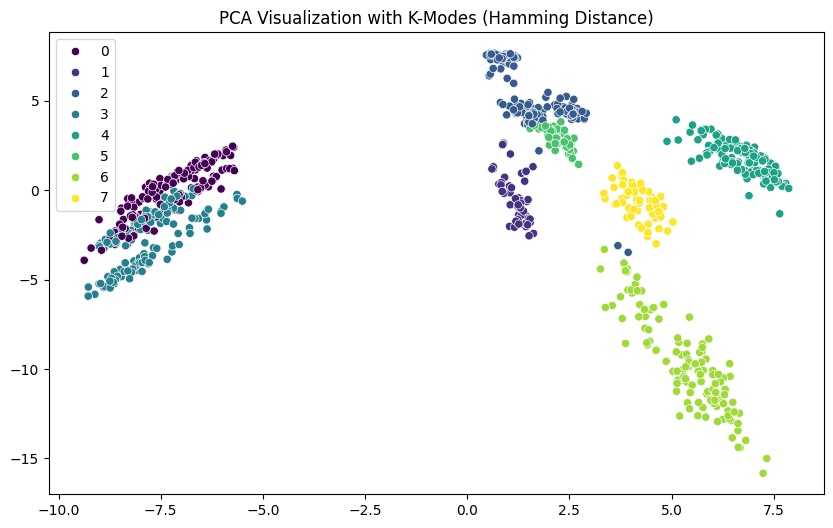

In [ ]:
kmodes_default = KModes(n_clusters=N_CLUSTER, init='Huang', n_init=5, verbose=1)
kmodes_default_labels = kmodes_default.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualize the PCA result with K-Modes (Default Hamming Distance)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmodes_default_labels, palette='viridis', legend='full')
plt.title('PCA Visualization with K-Modes (Hamming Distance)')
plt.show()

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 132, cost: 874706.0
Run 1, iteration: 2/100, moves: 44, cost: 874336.0
Run 1, iteration: 3/100, moves: 7, cost: 874266.0
Run 1, iteration: 4/100, moves: 5, cost: 874249.0
Run 1, iteration: 5/100, moves: 0, cost: 874249.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 131, cost: 875174.0
Run 2, iteration: 2/100, moves: 41, cost: 874729.0
Run 2, iteration: 3/100, moves: 16, cost: 874593.0
Run 2, iteration: 4/100, moves: 7, cost: 874527.0
Run 2, iteration: 5/100, moves: 7, cost: 874382.0
Run 2, iteration: 6/100, moves: 5, cost: 874331.0
Run 2, iteration: 7/100, moves: 2, cost: 874316.0
Run 2, iteration: 8/100, moves: 0, cost: 874316.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 185, cost: 873492.0
Run 3, iteration: 2/100, moves: 63, cost: 871376.0


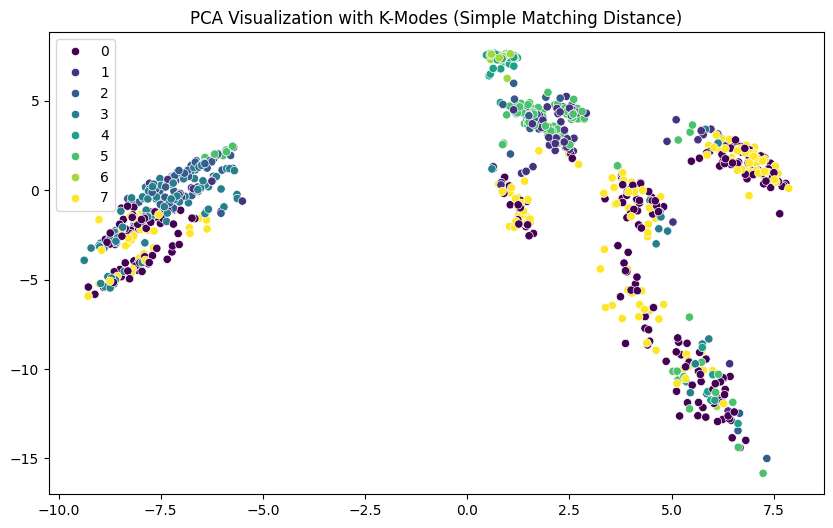

In [ ]:
# Step 3: K-Modes Clustering with Simple Matching Distance (Manually computed)
def simple_matching_distance(X):
    """Compute pairwise simple matching distance for binary data."""
    return pairwise_distances(X, metric='matching')

# Get the simple matching distance matrix
smd_matrix = simple_matching_distance(X)

# Apply K-Modes using the custom simple matching distance
kmodes_smd = KModes(n_clusters=N_CLUSTER, init='Huang', n_init=5, verbose=1)
kmodes_smd_labels = kmodes_smd.fit_predict(smd_matrix)

# Visualize the PCA result with K-Modes (Simple Matching Distance)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmodes_smd_labels, palette='viridis', legend='full')
plt.title('PCA Visualization with K-Modes (Simple Matching Distance)')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 40, cost: 915649.0
Run 1, iteration: 2/100, moves: 4, cost: 915578.0
Run 1, iteration: 3/100, moves: 1, cost: 915556.0
Run 1, iteration: 4/100, moves: 1, cost: 915542.0
Run 1, iteration: 5/100, moves: 0, cost: 915542.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 33, cost: 916568.0
Run 2, iteration: 2/100, moves: 2, cost: 916566.0
Run 2, iteration: 3/100, moves: 0, cost: 916566.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 24, cost: 916737.0
Run 3, iteration: 2/100, moves: 5, cost: 916531.0
Run 3, iteration: 3/100, moves: 0, cost: 916531.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 46, cost: 917735.0
Run 4, iteration: 2/100, moves: 2, cost: 917647.0
Run 4, iteration: 3/100, m

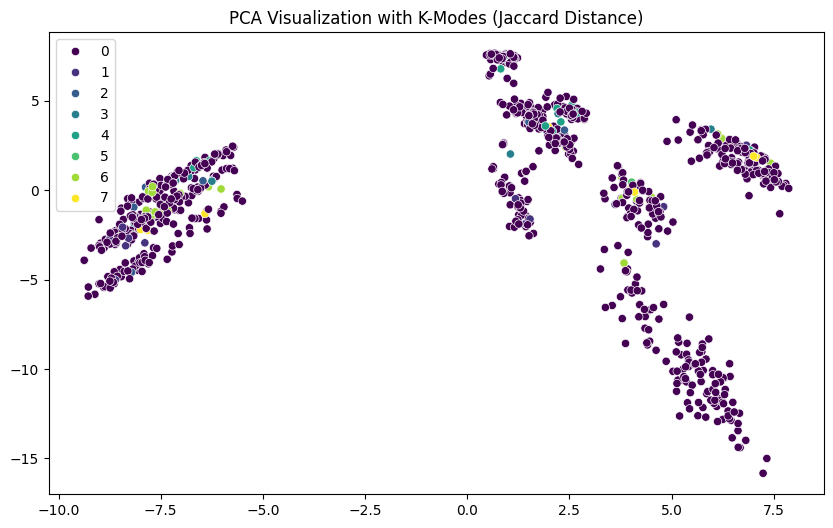

In [ ]:
def jaccard_distance(X):
    """Compute pairwise Jaccard distance for binary data."""
    return pairwise_distances(X, metric='jaccard')

# Get the Jaccard distance matrix
jaccard_matrix = jaccard_distance(X)

# Apply K-Modes using the custom Jaccard distance
kmodes_jaccard = KModes(n_clusters=N_CLUSTER, init='Huang', n_init=5, verbose=1)
kmodes_jaccard_labels = kmodes_jaccard.fit_predict(jaccard_matrix)

# Visualize the PCA result with K-Modes (Jaccard Distance)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmodes_jaccard_labels, palette='viridis', legend='full')
plt.title('PCA Visualization with K-Modes (Jaccard Distance)')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/pairwise.py:2361: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


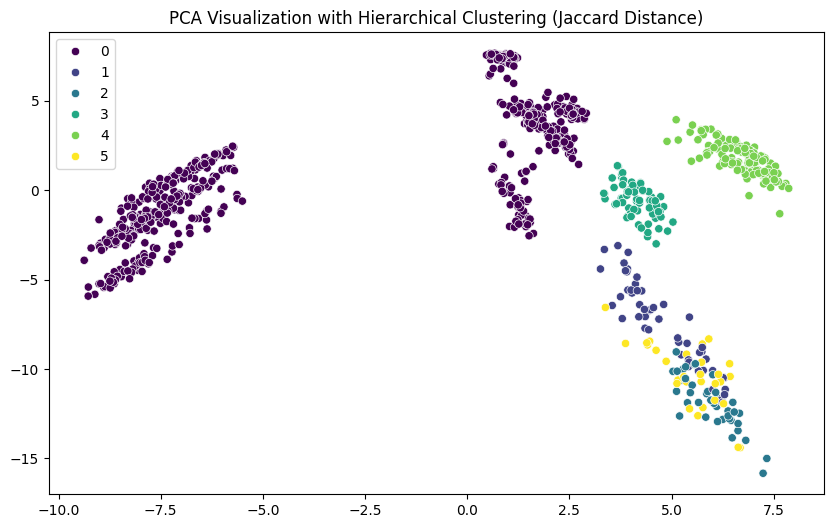

In [ ]:
def jaccard_distance(X):
    """Compute pairwise Jaccard distance for binary data."""
    return pairwise_distances(X, metric='jaccard')

# Get the Jaccard Distance matrix
jaccard_matrix = jaccard_distance(X)

# Apply Agglomerative Clustering with Jaccard Distance
agg_clustering_jaccard = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='complete')
agg_labels_jaccard = agg_clustering_jaccard.fit_predict(jaccard_matrix)

# Visualize the PCA result with Hierarchical Clustering (Jaccard Distance)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels_jaccard, palette='viridis', legend='full')
plt.title('PCA Visualization with Hierarchical Clustering (Jaccard Distance)')
plt.show()

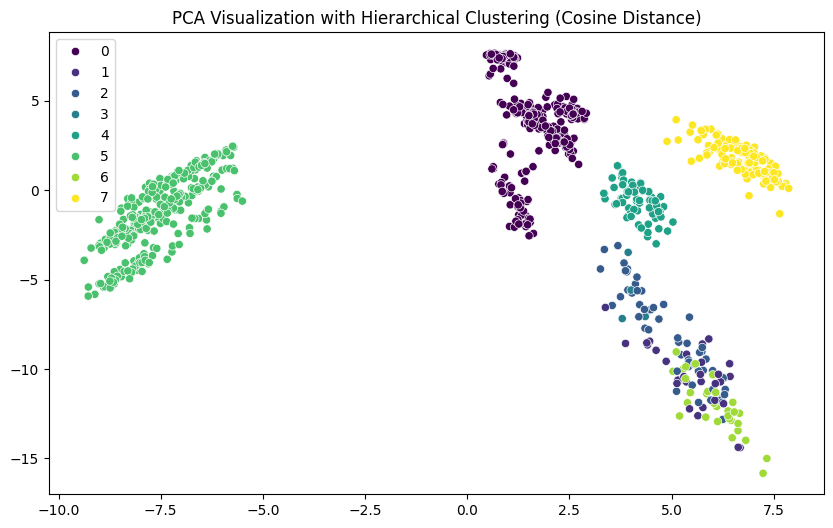

In [ ]:
def cosine_distance(X):
    """Compute pairwise simple matching distance for binary data."""
    return pairwise_distances(X, metric='cosine')

cosine_matrix = cosine_distance(X)

# Apply Agglomerative Clustering with Simple Matching Distance
agg_clustering_cosine = AgglomerativeClustering(n_clusters=N_CLUSTER, linkage='complete', metric='precomputed')
agg_labels_cosine = agg_clustering_cosine.fit_predict(cosine_matrix)

# Visualize the PCA result with Hierarchical Clustering (Cosine Distance)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels_cosine, palette='viridis', legend='full')
plt.title('PCA Visualization with Hierarchical Clustering (Cosine Distance)')
plt.show()

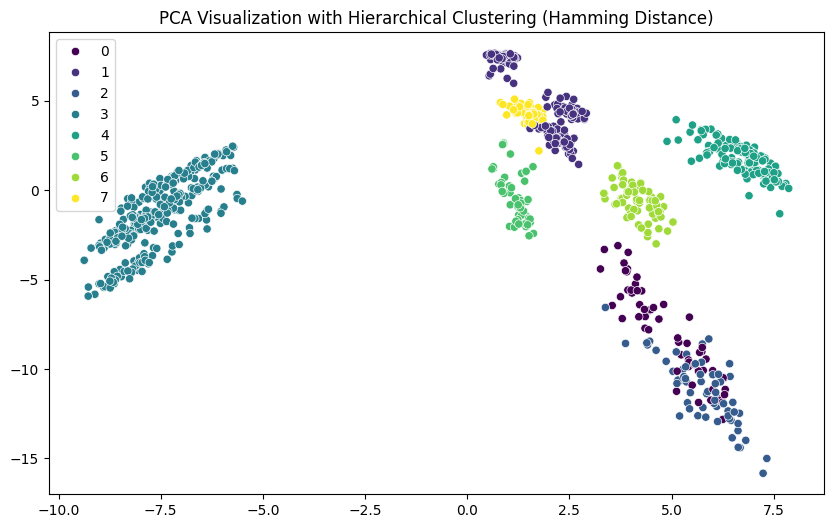

In [ ]:

def hamming(X):
    """Compute pairwise Hamming distance for binary data."""
    return pairwise_distances(X, metric='hamming')

# Get the Hamming Distance matrix
smd_matrix = hamming(X)

# Apply Agglomerative Clustering with Hamming Distance
agg_clustering_smd = AgglomerativeClustering(n_clusters=N_CLUSTER, linkage='complete', metric='precomputed')
agg_labels_smd = agg_clustering_smd.fit_predict(smd_matrix)

# Visualize the PCA result with Hierarchical Clustering (Hamming Distance)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels_smd, palette='viridis', legend='full')
plt.title('PCA Visualization with Hierarchical Clustering (Hamming Distance)')
plt.show()


### Visualize results using the dimensionality reduction (UMAP or tSNE) techniques with respect to the cluster labels.


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


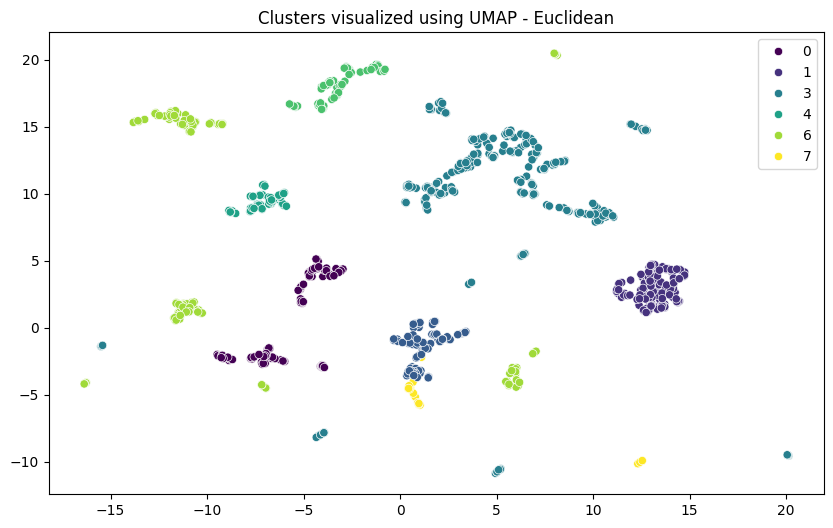

In [ ]:
# Using UMAP for dimensionality reduction
umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42, metric='euclidean')
X_umap = umap_model.fit_transform(X)

# Visualizing the clusters using UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=kmeans.labels_, palette='viridis')
plt.title('Clusters visualized using UMAP - Euclidean')
plt.show()

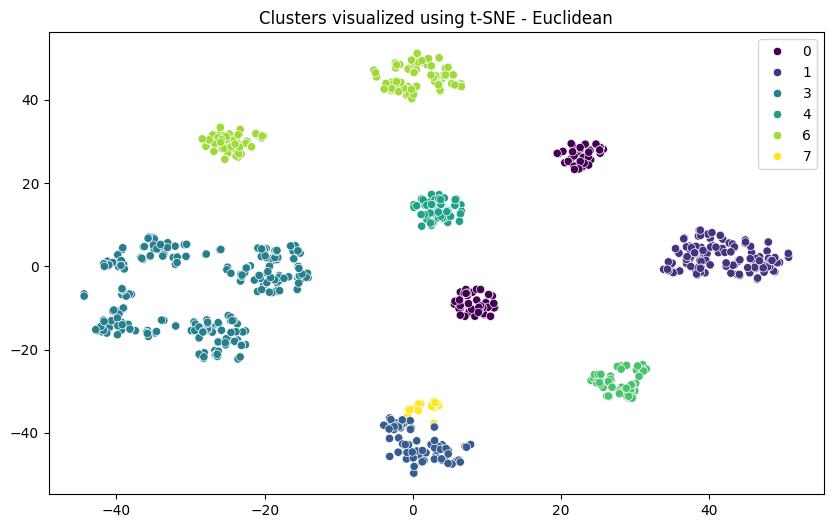

In [ ]:
# Using t-SNE for dimensionality reduction
tsne_model = TSNE(n_components=2, random_state=42, metric='euclidean')
X_tsne = tsne_model.fit_transform(X)

# Visualizing the clusters using t-SNE
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans.labels_, palette='viridis')
plt.title('Clusters visualized using t-SNE - Euclidean')
plt.show()


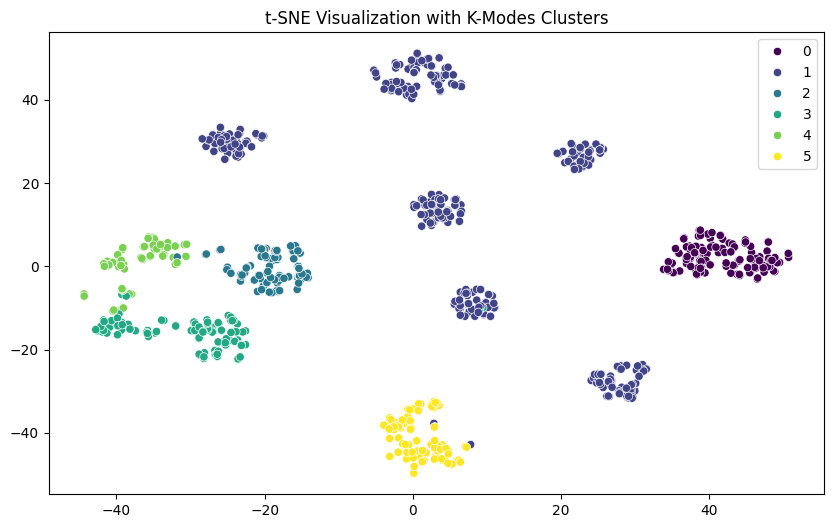

In [ ]:
kmodes = KModes(n_clusters=N_CLUSTER, init='Huang', n_init=5, verbose=1)
kmodes_labels = kmodes.fit_predict(X)
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmodes_labels, palette='viridis', legend='full')
plt.title('t-SNE Visualization with K-Modes Clusters')
plt.show()

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


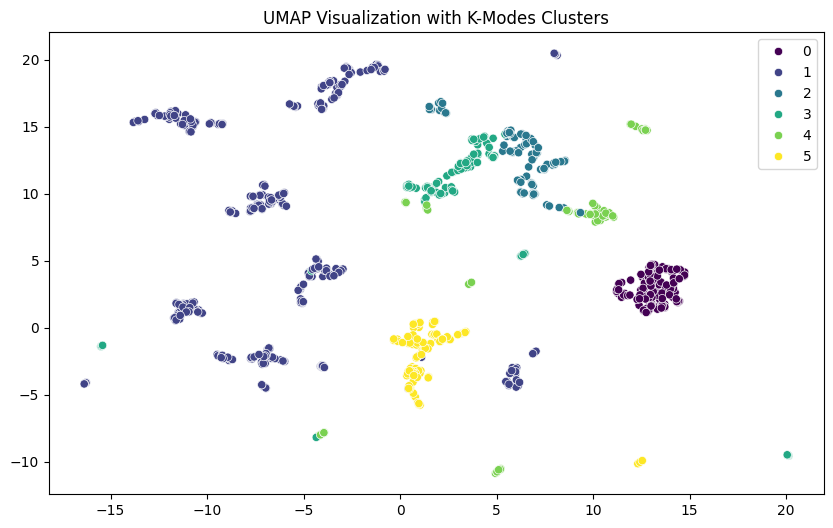

In [ ]:
kmodes = KModes(n_clusters=N_CLUSTER, init='Huang', n_init=5, verbose=1)
kmodes_labels = kmodes.fit_predict(X)
umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

# Step 4: Visualize the UMAP embedding with K-Modes clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=kmodes_labels, palette='viridis', legend='full')
plt.title('UMAP Visualization with K-Modes Clusters')
plt.show()

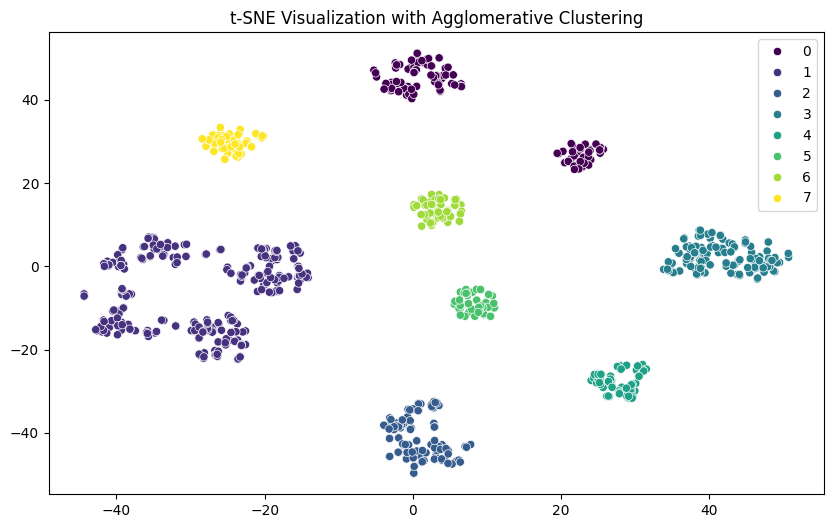

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


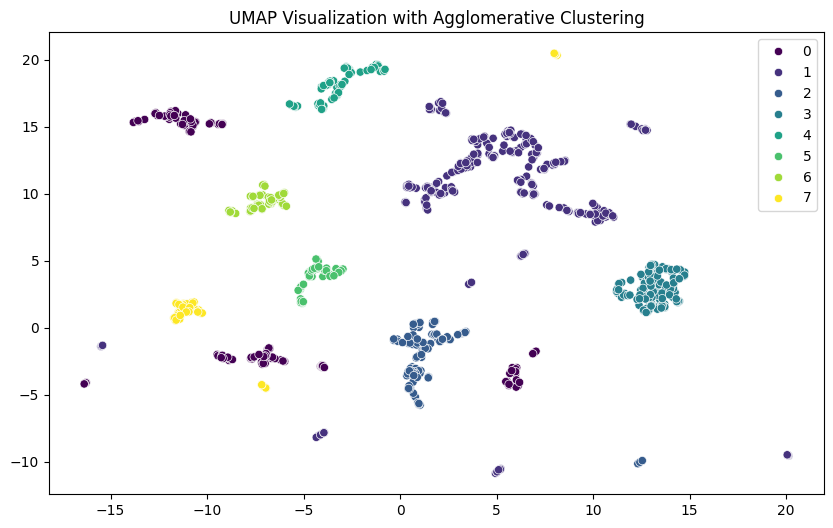

In [ ]:
agg_clustering = AgglomerativeClustering(n_clusters=N_CLUSTER, linkage='ward')
agg_labels = agg_clustering.fit_predict(X)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=agg_labels, palette='viridis', legend='full')
plt.title('t-SNE Visualization with Agglomerative Clustering')
plt.show()


umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=agg_labels, palette='viridis', legend='full')
plt.title('UMAP Visualization with Agglomerative Clustering')
plt.show()


### Compare clustering results. Try to rationalize observed commonalities or differences with respect to clustering methods and distance metrics used.

The dataset comprises binary values spread across 969 rows and 1025 columns.

After loading the data, performing K-Means clustering gives an optimal number of clusters of around 8, as observed from the Elbow and Silhouette Methods graph plots.

K-means is an unsupervised algorithm for clustering, thus we do not need to provide target variables to K-means. It uses mathematical measures (distance) to cluster continuous data. The shorter the distance, the more similar are the data points. Centroids are updated by computing the mean.

However, for categorical data points, we cannot calculate the distance. So we go for the K-Mode algorithm. K-mode clustering is an unsupervised machine-learning technique used to group a set of data objects into a specified number of clusters, based on their categorical attributes. The algorithm is called “K-Mode” because it uses modes (i.e. the most frequent values) instead of means or medians to represent the clusters. It uses the dissimilarities(total mismatches) between the data points. The lesser the dissimilarities the more similar our data points are.

Next, when performing clustering with different methods as implemented in Scikit-learn, we used 8 clusters to perform: agglomerative clustering, spectral clustering, and Gaussian clustering.

Clustering binary data using K-Means is challenging due to the Euclidean distance measure reducing to counting disagreements between cases, leading to ties and arbitrary cluster assignments. Although iterations update cluster centers to represent the proportions of ones, the initial arbitrary assignments often persist, resulting in unstable or non-meaningful clusters.

Therefore, hierarchical clustering can be used with binary data by choosing an appropriate distance metric, such as Jaccard distance or Hamming distance. It offers a better alternative but is more memory-intensive. Alternatively, factor or principal component analysis can transform binary data into continuous variables for more effective clustering.

K- Mode is also ideal for clustering categorical data. It is an adaptation of K-Means specifically designed for categorical data, including binary data.

In the case of K-modes, these distances are calculated using a dissimilarity measure called the Hamming distance. The Hamming distance between two data objects is the number of categorical attributes that differ between the two objects.

Now, trying clustering with different distance metrics on K-means, K-mode, and hierarchical clustering, yields various graphical visualizations. The default distance metric for K-means is Euclidean distance which gives a good cluster representation however as the data is Binary, it can be seen there is some clustering which is not very conclusive. Upon trying other methods of distance measurement with K-means, the conclusive cluster formation seems to be improving, therefore it is safe to say that the default distance metric for K-means is not appropriate for our dataset here.
For K-mode clustering, the default metric is Hamming Distance. This metric is able to provide a good cluster representation of the dataset, given K-mode is a good choice for Binary datasets. Here, the default metric is the best one to consider when compared with other distance metrics for K-mode clustering such as Simple Matching Distance or Jaccard Distance.

For Hierarchical Clustering, the default metric is Jaccard Distance. It is able to represent proper clusters however the intra-cluster distance is too high for certain clusters, thereby proving to be an inappropriate choice for the dataset. For hierarchical clustering, other distance metrics such as Cosine or Hamming provide better cluster representations.

Now, visualizing the results with dimensionality reduction techniques such as UMAP or t-SNE, on comparing with the previous cluster visualizations using PCA, it can be observed that PCA is primarily designed for continuous data, as it identifies directions (principal components) in which the data varies the most. When applied to binary data, PCA may not effectively capture the structure since binary data lacks continuous variance.
Despite this, PCA can still be applied, however, it may not yield meaningful components that represent the underlying binary structure accurately. Also, PCA is generally not recommended for binary datasets when using K-mode clustering due to its reliance on continuous variance and potential loss of categorical interpretability.
UMAP and t-SNE are more suitable for binary datasets, especially for exploratory analysis and visualization, followed by clustering.
Hierarchical Clustering can effectively leverage UMAP or t-SNE outputs for enhanced clustering results, as these techniques maintain more of the structure in the data compared to PCA.

